# Importing Libraries

In [1]:
from PIL import Image
from PIL.ExifTags import TAGS, GPSTAGS
import numpy as np
import pandas as pd
import time
import random
import matplotlib.pyplot as plt
import os
import piexif
import math
from math import sin, cos, sqrt, atan2, radians

# Loading All Images from a folder

In [2]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        images.append(filename)
    return images

# Entering File Location

In [17]:
filename=load_images_from_folder("C:\\Users\\Rohit\Documents\Mega Project\Simulation\chennai flood/")

# Converting decimal degrees to degree, minute, second

In [15]:
def decdeg2dms(dd):
    mnt,sec = divmod(dd*3600,60)
    deg,mnt = divmod(mnt,60)
    return deg,mnt,sec

In [7]:
#List of cluster centers in chennai
centerlat=[13.1187,13.0764,13.0086,12.8389,12.932294,13.001666]
centerlon=[80.2622,80.2073,80.2186,80.2165,80.182318, 80.137055]

In [8]:
#List of cluster centers in mumbai
centerlat=[19.2313,18.9652,19.2380,19.0058,19.1849,19.1159,19.0600,19.1166,19.1628,19.2168,19.1369]
centerlon=[72.7945,72.8219,72.8531,72.8439,72.8494,72.8510,72.8966,72.9103,72.9502,72.9790,72.8314]

# (First Method) Function to calculate distance between two coordinates

In [9]:
def distance(originlat,originlon,destlat,destlon):
    from math import sin, cos, sqrt, atan2, radians
    lat=[0,0]
    lon=[0,0]
    R=6373.0
    lat[0]=radians(originlat)
    lon[0]=radians(originlon)
    lat[1]=radians(destlat)
    lon[1]=radians(destlon)
    dlon=lon[1]-lon[0]
    dlat=lat[1]-lat[0]
    a= sin(dlat/ 2)**2 + cos(lat[0]) * cos(lat[1]) * sin(dlon/ 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
  #  print(originlat,",",originlon,",",destlat,",",destlon)
    distance = R * c
    return distance

# Method 1: Generating random coordinates within a rectangular boundary and selecting the point if it is within 2 Km radius 

In [132]:
destlat=0
destlon=0
index=0

val=494 # Total images in the folder

cluster_size=0
cluster=[]

source = "mumbai flood"
dest = "test_mumbai_1"

for i in range(len(centerlat)):
    
    if(i==len(centerlat)-1):
        cluster_size=val
        
        
    if(val>0):       
        cluster_size=random.randrange(20,50,1) #Having a cluster size within 30 to 80
    
    val = val-cluster_size 
    
    cluster.append(cluster_size)
        
    for j in range(cluster_size): 
        try:
            img = Image.open(source + "/"+filename[index])
            img=img.convert('RGB')
            while(1):
                destlat=random.randrange(188927,193032,33) #manually enter the latitude*10000 range and the steps
                destlon=random.randrange(727799,730118,18) #manually enter the longitude*10000 range and the steps
                x=distance(centerlat[i],centerlon[i],destlat/10000,destlon/10000)
                
                if(x<2): #If distance is <2 Km, we break out of the infinite loop
                    break                
            
            #Converting decimal degree to degree, minute, second
            deglat,mntlat,seclat=decdeg2dms(destlat/10000)
            deglon,mntlon,seclon=decdeg2dms(destlon/10000)
            
            #Preparing the structure of coordinate data
            gps_ifd = {piexif.GPSIFD.GPSVersionID: (2, 0, 0, 0),
                   piexif.GPSIFD.GPSLatitude: ((int(deglat), 1), (int(mntlat), 1), (int(seclat*10000),10000)),
                   piexif.GPSIFD.GPSLongitude:((int(deglon), 1), (int(mntlon), 1), (int(seclon*10000),10000)),
                   piexif.GPSIFD.GPSDateStamp: u"1999:99:99 99:99:99",
                   }
            exif_dict = {"GPS":gps_ifd}
            exif_bytes = piexif.dump(exif_dict)
            
            #print(filename[index])
            
            #Save image in desxtination folder
            img.save(dest + "/" + filename[index], exif=exif_bytes)
            index=index+1
            
        except:
            index=index+1
            continue

In [133]:
cluster #No. of points in each cluster

[36, 36, 30, 43, 44, 26, 26, 47, 49, 39, 39]

# Method 2: Generating random coordinates from a normal multivariate distribution within a rectangular boundary and selecting a point within it

In [151]:
destlat=0
destlon=0

index=0

val=494 # Total images in the folder

cluster_size=0
cluster=[]

source = "mumbai flood"
dest = "test_mumbai_2"

for i in range(len(centerlat)):
    
    if(i==len(centerlat)-1):
        cluster_size=val
    
    if(val>0):       
        cluster_size=random.randrange(20,50,1)
        
    val = val-cluster_size
            
    cluster.append(cluster_size)
    
    x, y = np.random.multivariate_normal([centerlat[i], centerlon[i]], [[1, 0],[0, 1]],cluster_size).T
    
    x=(x-min(x))/(max(x)-min(x)) #Normalization
    y=(y-min(y))/(max(y)-min(y)) #Normalization
    
    x=centerlat[i]-0.02+0.04*x #Going 2km down and multiplying 4km with a value picked from a normal distribution
    y=centerlon[i]-0.02+0.04*y #Going 2km left and multiplying 4km with a value picked from a normal distribution
    
    for j in range(cluster_size):
        try:
            
            img = Image.open(source + "/" + filename[index])
            
            img=img.convert('RGB')
            
            deglat,mntlat,seclat=decdeg2dms(x[j])
            deglon,mntlon,seclon=decdeg2dms(y[j])
            

            gps_ifd = {piexif.GPSIFD.GPSVersionID: (2, 0, 0, 0),
                   piexif.GPSIFD.GPSLatitude: ((int(deglat), 1), (int(mntlat), 1), (int(seclat*10000),10000)),
                   piexif.GPSIFD.GPSLongitude:((int(deglon), 1), (int(mntlon), 1), (int(seclon*10000),10000)),
                   piexif.GPSIFD.GPSDateStamp: u"1999:99:99 99:99:99",
                   }
            exif_dict = {"GPS":gps_ifd}
            exif_bytes = piexif.dump(exif_dict)
            
            #print(filename[index])
            
            img.save(dest + "/" + filename[index], exif=exif_bytes)
            index=index+1
            
        except:
            index=index+1
            continue

In [152]:
cluster #No. of points in each cluster

[41, 26, 30, 23, 20, 47, 43, 37, 28, 32, 35]

# Extracting Geolocation Data From Images

In [122]:
class ImageMetaData(object):
    exif_data = None
    image = None

    def __init__(self, img_path):
        self.image = Image.open(img_path)
        #print(self.image._getexif())
        self.get_exif_data()
        super(ImageMetaData, self).__init__()

    def get_exif_data(self):
        """Returns a dictionary from the exif data of an PIL Image item. Also converts the GPS Tags"""
        exif_data = {}
        info = self.image._getexif()
        if info:
            for tag, value in info.items():
                decoded = TAGS.get(tag, tag)
                if decoded == "GPSInfo":
                    gps_data = {}
                    for t in value:
                        sub_decoded = GPSTAGS.get(t, t)
                        gps_data[sub_decoded] = value[t]

                    exif_data[decoded] = gps_data
                else:
                    exif_data[decoded] = value
                    
        self.exif_data = exif_data
        return exif_data

    def get_if_exist(self, data, key):
        if key in data:
            return data[key]
        return None

    def convert_to_degress(self, value):

        """Helper function to convert the GPS coordinates 
        stored in the EXIF to degress in float format"""
        d0 = value[0]
        d = float(d0)

        m0 = value[1]
        m = float(m0)

        s0 = value[2]
        s = float(s0)

        return d + (m / 60.0) + (s / 3600.0)

    def get_lat_lng(self):
        """Returns the latitude and longitude, if available, from the provided exif_data (obtained through get_exif_data above)"""
        lat = None
        lng = None
        exif_data = self.get_exif_data()
        if "GPSInfo" in exif_data:      
            gps_info = exif_data["GPSInfo"]
            gps_latitude = self.get_if_exist(gps_info, "GPSLatitude")
            gps_latitude_ref = self.get_if_exist(gps_info, 'GPSLatitudeRef')
            gps_longitude = self.get_if_exist(gps_info, 'GPSLongitude')
            gps_longitude_ref = self.get_if_exist(gps_info, 'GPSLongitudeRef')
            if gps_latitude and gps_longitude:
                lat = self.convert_to_degress(gps_latitude)
                lng = self.convert_to_degress(gps_longitude)
        return lat, lng

# Reading file having images with simulated locations

In [147]:
source = "test_mumbai_1"
filename=load_images_from_folder(source + "/")

# Getting latitude and longitude of images

In [148]:
lat =[]
lng = []
for i in range(len(filename)):
    path_name = source + "/" + filename[i]
    meta_data =  ImageMetaData(path_name)
    x, y= meta_data.get_lat_lng()
    lat.append(x)
    lng.append(y)

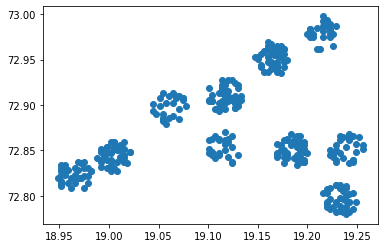

In [149]:
plt.scatter(lat,lng)

# (Second Method) Suggested by Ashish Sir

In [4]:
# Anna arch Arumbakkam, thayapa, Varathammal Garden 3rd St(TNHB Colony Purasaiwakkam), Natesa nagar, perambur, tondiarpet, Joseph Hospitals (near kilpauk ektu upore), The Madras Medical Mission Hospital, Government Peripheral Hospital (Anna Nagar), Ganapathy Colony
centres=[[80.2179, 13.0765],[80.2847, 13.1023],[80.247043, 13.093221],[80.1938, 13.0586],[80.2326, 13.1210],[80.2880, 13.1261],[80.234037, 13.075537],[80.1874, 13.0861],[80.2193, 13.0955],[80.2607, 13.0512]]
sd2=[0.0025,0.0015,0.0035,0.0045,0.0045,0.0035,0.0015,0.0035,0.0025,0.0055]

In [5]:
data=[]

for i in range(10):
    src=centres[i]
    r=sd2[i]

    np.random.seed(i)

    no=13+6*i
    
    value1 = np.random.normal(src[0],r,no)
    value2 = np.random.normal(src[1],r,no)
    
    for j in range(no):
        x_cord=value1[j]
        y_cord=value2[j]
        
        data.append([x_cord,y_cord])
    
print(data[0])

[80.22231013086493, 13.076804187541232]


In [6]:
np.random.seed(42)
rectangle_leftcorner=[[80.144705, 13.018443],[80.280661, 13.026470],[80.290445, 13.072124],[80.295252, 13.111081]]
rectangle_rightcorner=[[80.108313, 13.069950],[80.152601, 13.069950],[80.150026, 13.111416],[80.192255, 13.132480]]
no=[20,30,20,30]

for i in range(len(no)):
    lng_rand=np.random.rand(no[i])
    lat_rand=np.random.rand(no[i])
    k=0

    lng_min=min(rectangle_leftcorner[i][0],rectangle_rightcorner[i][0])
    lng_max=max(rectangle_leftcorner[i][0],rectangle_rightcorner[i][0])
    lat_min=min(rectangle_leftcorner[i][1],rectangle_rightcorner[i][1])
    lat_max=max(rectangle_leftcorner[i][1],rectangle_rightcorner[i][1])

    for j in range(no[i]):
        x_cord=lng_min+lng_rand[j]*(lng_max-lng_min)
        y_cord=lat_min+lat_rand[j]*(lat_max-lat_min)
        data.append([x_cord,y_cord])

In [7]:
df=pd.DataFrame(data,columns=['lng','lat'])
df

,lng,lat
0,80.222310,13.076804
1,80.218900,13.077610
2,80.220347,13.077334
3,80.223502,13.080235
4,80.222569,13.075987
...,...,...
495,80.278289,13.118554
496,80.225294,13.126616
497,80.211466,13.130278
498,80.196455,13.130064


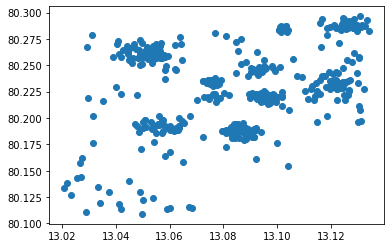

In [8]:
plt.scatter(df.loc[:,"lat"],df.loc[:,"lng"])

In [37]:
destlat=0
destlon=0

index=0

val=494 # Total images in the folder

cluster_size=0
cluster=[]

source = "C:\\Users\Rohit\Documents\Mega Project\Simulation\chennai flood"
dest = "C:\\Users\Rohit\Documents\Mega Project\Simulation\chennai flood_new_method"



In [41]:
index=0
for i in range(len(df)):
    try:
        img = Image.open(source + "/" + filename[index])

        img=img.convert('RGB')

        deglat,mntlat,seclat=decdeg2dms(df["lat"][i])
        deglon,mntlon,seclon=decdeg2dms(df["lng"][i])
    

        gps_ifd = {piexif.GPSIFD.GPSVersionID: (2, 0, 0, 0),
               piexif.GPSIFD.GPSLatitude: ((int(deglat), 1), (int(mntlat), 1), (int(seclat*10000),10000)),
               piexif.GPSIFD.GPSLongitude:((int(deglon), 1), (int(mntlon), 1), (int(seclon*10000),10000)),
               piexif.GPSIFD.GPSDateStamp: u"1999:99:99 99:99:99",
               }
        exif_dict = {"GPS":gps_ifd}
        exif_bytes = piexif.dump(exif_dict)

        print(filename[index])

        img.save(dest + "/" + filename[index], exif=exif_bytes)
        index=index+1

    except Exception as e:
        print(e)
        index=index+1
        continue

chennai flood_1.jpg
chennai flood_10.jpg
chennai flood_100.jpg
chennai flood_101.jpg
chennai flood_102.jpg
chennai flood_103.jpg
chennai flood_104.jpg
chennai flood_105.jpg
chennai flood_106.jpg
chennai flood_107.jpg
chennai flood_108.jpg
chennai flood_109.jpg
chennai flood_11.jpg
chennai flood_110.jpeg
chennai flood_111.jpg
chennai flood_112.jpg
chennai flood_113.jpg
chennai flood_114.png
chennai flood_115.jpg
chennai flood_116.jpg
chennai flood_117.jpg
chennai flood_118.jpg
chennai flood_119.jpg
chennai flood_12.jpg
chennai flood_120.jpg
chennai flood_121.jpg
chennai flood_122.jpg
chennai flood_123.jpg
chennai flood_124.jpg
chennai flood_125.jpeg
chennai flood_126.jpg
chennai flood_127.jpg
chennai flood_128.jpg
chennai flood_129.jpg
chennai flood_13.jpg
chennai flood_130.jpg
chennai flood_131.jpg
chennai flood_132.jpg
chennai flood_133.jpg
chennai flood_134.jpg
chennai flood_135.jpg
chennai flood_136.jpg
chennai flood_137.jpg
chennai flood_138.jpg
chennai flood_139.jpg
chennai flood_

chennai flood_473.jpg
chennai flood_474.jpg
chennai flood_475.jpg
chennai flood_476.jpg
chennai flood_477.jpg
chennai flood_478.jpg
chennai flood_479.jpg
chennai flood_48.jpg
chennai flood_480.jpg
chennai flood_482.jpg
chennai flood_483.jpg
chennai flood_484.jpg
chennai flood_485.jpg
chennai flood_486.jpg
chennai flood_487.jpg
chennai flood_488.jpg
chennai flood_489.jpg
chennai flood_49.jpg
chennai flood_490.jpg
chennai flood_491.jpg
chennai flood_492.jpg
chennai flood_494.jpg
chennai flood_495.jpg
chennai flood_496.jpeg
chennai flood_497.jpg
chennai flood_498.jpg
chennai flood_499.jpg
chennai flood_5.jpg
chennai flood_50.jpg
chennai flood_500.png
chennai flood_501.jpg
chennai flood_502.jpg
chennai flood_503.jpg
chennai flood_504.jpg
chennai flood_505.jpg
chennai flood_506.jpg
chennai flood_507.jpg
chennai flood_508.jpeg
chennai flood_509.jpg
chennai flood_51.jpg
chennai flood_510.jpg
chennai flood_511.jpg
chennai flood_512.png
chennai flood_513.jpg
chennai flood_514.jpg
chennai flood_

In [13]:
df["lat"][0]

13.076804187541232